# Zadanie 2: PageRank z teleportacją i obsługą wierzchołków wiszących

## 1. Wprowadzenie
Podstawowy model błądzenia przypadkowego z Zadania 1 jest niewystarczający dla rzeczywistych grafów (takich jak struktura sieci WWW). Napotyka on na dwa główne problemy:
1. **Wierzchołki wiszące (Dangling nodes):** Węzły bez krawędzi wychodzących, które działają jak "czarne dziury", pochłaniając masę prawdopodobieństwa w kolejnych iteracjach.
2. **Spider traps:** Zamknięte cykle, z których nie ma wyjścia, co zaburza globalny ranking.

Aby rozwiązać te problemy, do modelu wprowadzono mechanizm **teleportacji** – z prawdopodobieństwem $(1-d)$ "surfer" ignoruje strukturę krawędzi i przeskakuje do losowego wierzchołka zgodnie z wektorem preferencji $e$. Równanie przybiera postać:
$$r(u) = d \sum_{v \in B_u} \frac{r(v)}{N_v} + (1-d)e(u)$$

In [18]:
import numpy as np
from numpy import linalg as LA
import networkx as nx
import matplotlib.pyplot as plt
import time

<h1>Pomocnicze funkcji</h1>

In [19]:
def build_sparse_transition_matrix(adj_list, n):
    A = np.zeros((n, n))
    for u, neighbors in adj_list.items():
        out_degree = len(neighbors)
        if out_degree > 0:
            for v in neighbors:
                A[v, u] = 1.0 / out_degree
    return A

In [20]:
def load_snap_dataset(filepath):
    adj_list = {}
    max_node_id = 0
    
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
                
            u, v = map(int, line.split())
            
            if u not in adj_list:
                adj_list[u] = []
            adj_list[u].append(v)
            
            if u > max_node_id: max_node_id = u
            if v > max_node_id: max_node_id = v
            
    n_nodes = max_node_id + 1
    return adj_list, n_nodes

In [21]:
def power_method(B, max_iter=10000, tol=1e-8):

    n = B.shape[0]
    r = np.ones(n) / n
    
    for i in range(1, max_iter + 1):
        r_new = B @ r
        
        r_new = r_new / np.sum(np.abs(r_new))
        
        if LA.norm(r_new - r, 1) < tol:
            r = r_new
            break
            
        r = r_new
        
    return r, i

## 2. Optymalizacja pamięciowa: Algorytm z redystrybucją masy

Teoretycznie, problem teleportacji i wierzchołków wiszących można rozwiązać budując pełną macierz Google $B$. Jednakże macierz ta jest gęsta, a jej przechowywanie wymaga pamięci rzędu $O(n^2)$. Dla dużych grafów  jest to awykonalne.

Zamiast tego zaimplementowano **Algorytm 1 z redystrybucją masy**. Algorytm ten:
1. Przechowuje graf wyłącznie w postaci rzadkiej listy sąsiedztwa, realizując mnożenie $d A r_i$ w czasie $O(|V| + |E|)$.
2. Jawnie oblicza masę utraconą na skutek tłumienia oraz istnienia wierzchołków wiszących: $\rho = ||r_i||_1 - ||r_{i+1}||_1$.
3. Przywraca stochastyczność modelu poprzez rozdzielenie utraconej masy proporcjonalnie do wektora teleportacji $e$: $r_{i+1} = r_{i+1} + \rho e$.

In [22]:
def pagerank_algorithm(adj_list, n, d=0.85, e=None, max_iter=10000, tol=1e-8):
    if e is None:
        e = np.ones(n) / n
    else:
        e = np.asarray(e)
        
    r = np.copy(e)
    history = []
    
    for i in range(1, max_iter + 1):
        # Create an empty vector for the next iteration
        r_new = np.zeros(n)
        
        for u, neighbors in adj_list.items():
            out_degree = len(neighbors)
            if out_degree > 0:
                # Probability mass distributed by node u to each neighbor
                share = (r[u] * d) / out_degree
                for nei in neighbors:
                    r_new[nei] += share
                    
        # Compute the lost probability mass  
        lost_mass = np.sum(r) - np.sum(r_new)
        
        # Redistribution: spread the lost mass according to vector e
        r_new += lost_mass * e
        
        # Check convergence
        delta = LA.norm(r_new - r, 1)
        history.append(delta)
        
        if delta < tol:
            r = r_new
            break
            
        r = r_new
        
    return r, history, i

### Implementacja referencyjna: Gęsta macierz Google $B$

Poniższa funkcja to implementacja algorytmu PageRank poprzez jawne skonstruowanie gęstej macierzy Google $B$. Wymaga dużej ilości pamięci w przypadku dużych wartości $n$.

Proces budowy macierzy przebiega w następujących krokach matematycznych:

1. Konstrukcja bazowej macierzy przejścia $A$.
2. Zdefiniowanie wektora kolumnowego preferencji $e$.
3. Identyfikacja wierzchołków wiszących i utworzenie wektora wskaźnikowego $c$, gdzie $c_u=1$, jeśli węzeł $u$ nie posiada krawędzi wychodzących.
4. Stworzenie kolumnowo-stochastycznej macierzy $\hat{A}$, w której puste kolumny dla wierzchołków wiszących zastąpiono wektorem teleportacji $e$:
$$\hat{A}=A+ec^T$$
5. Zbudowanie ostatecznej macierzy Google ($B$), która uwzględnia parametr tłumienia $d$ oraz prawdopodobieństwo teleportacji do dowolnego węzła $(1-d)$:
$$B=d\hat{A}+(1-d)e 1^T$$

Ostateczny wektor PageRank jest dominującym wektorem własnym macierzy $B$, który w tej funkcji obliczany jest za pomocą metody potęgowej.

In [ ]:
def pagerank_dense_reference(adj_list, n, d=0.85, e=None):
    A = build_sparse_transition_matrix(adj_list, n)
    
    # Initialize preference vector e as a column vector
    e = np.ones((n, 1)) / n if e is None else np.asarray(e).reshape(-1, 1)
        
    # c is the dangling node indicator vector
    c = np.zeros((n, 1))
    for u in range(n):
        # If node u has no outgoing edges, mark it as dangling
        if u not in adj_list or len(adj_list[u]) == 0:
            c[u, 0] = 1.0
            
    # Fix matrix A: A_hat = A + e * c^T
    A_hat = A + e @ c.T
    
    # Build final Google Matrix: B = d * A_hat + (1 - d) * e * 1^T
    ones_T = np.ones((1, n))
    B = d * A_hat + (1.0 - d) * e @ ones_T
    
    # Find the dominant eigenvector corresponding to eigenvalue 1
    dominant_vec, iterations, = power_method(B)
    
    return dominant_vec.flatten(), iterations


## 3. Weryfikacja matematyczna implementacji

Aby upewnić się o bezbłędności Algorytmu 1, na niewielkim grafie testowym przeprowadzono weryfikację krzyżową z dwiema innymi metodami:
1. **(Dense B Matrix):** Bezpośrednia konstrukcja macierzy $\hat{A} = A + ec^T$  (gdzie $c$ to wektor wskaźnikowy wierzchołków wiszących) oraz macierzy $B$. Dominujący wektor własny odnaleziono standardową metodą potęgową.
2. **Podejście referencyjne:** Zastosowanie gotowej funkcji `networkx.pagerank`.

Obliczenie normy $L_1$ potwierdza, że zoptymalizowany pod kątem pamięci Algorytm 1 zwraca analitycznie tożsame rezultaty.

In [ ]:
n_nodes = 15
G = nx.erdos_renyi_graph(n=n_nodes, p=0.3, directed=True)

if not nx.is_strongly_connected(G):
    nodes = list(G.nodes())
    for i in range(len(nodes)):
        G.add_edge(nodes[i], nodes[(i + 1) % len(nodes)])

graph_adj_list = nx.to_dict_of_lists(G)


e_vector = np.ones(n_nodes) / n_nodes
damping_factor = 0.85



# Run Algorithm 1
start_time = time.time()
pr_alg,_, it_alg1 = pagerank_algorithm(graph_adj_list, n_nodes, d=damping_factor, e=e_vector)
time_alg1 = time.time() - start_time



# Run Dense Reference Matrix B
start_time = time.time()
pr_dense, it_dense = pagerank_dense_reference(graph_adj_list, n_nodes, d=damping_factor, e=e_vector)
time_dense = time.time() - start_time



# Run NetworkX Validation
G = nx.DiGraph(graph_adj_list)

personalization_dict = {i: e_vector[i] for i in range(n_nodes)}

start_time = time.time()
pr_nx_dict = nx.pagerank(G, alpha=damping_factor, personalization=personalization_dict, tol=1e-8)
time_nx = time.time() - start_time
pr_nx = np.array([pr_nx_dict[i] for i in range(n_nodes)])



# --- RESULTS ---
print("--- PageRank Results Comparison ---")
print(f"Algorithm 1 (Mass Redistribution): {it_alg1} iterations")
print(f"Algorithm 2 (Dense B Power Method): {it_dense} iterations")
print("-" * 50)

for i in range(n_nodes):
    print(f"Node {i}: Alg 1 = {pr_alg[i]:.6f} | Dense B = {pr_dense[i]:.6f} | NetworkX = {pr_nx[i]:.6f}")
    
diff_1_2 = LA.norm(pr_alg - pr_dense, 1)
diff_1_nx = LA.norm(pr_alg - pr_nx, 1)


print("-" * 50)
print(f"L1 Difference (Alg 1 vs Dense B) : {diff_1_2:.2e}")
print(f"L1 Difference (Alg 1 vs NetworkX): {diff_1_nx:.2e}")


--- PageRank Results Comparison ---
Algorithm 1 (Mass Redistribution): 18 iterations
Algorithm 2 (Dense B Power Method): 18 iterations
--------------------------------------------------
Node 0: Alg 1 = 0.080604 | Dense B = 0.080604 | NetworkX = 0.080604
Node 1: Alg 1 = 0.048397 | Dense B = 0.048397 | NetworkX = 0.048397
Node 2: Alg 1 = 0.083781 | Dense B = 0.083781 | NetworkX = 0.083781
Node 3: Alg 1 = 0.055697 | Dense B = 0.055697 | NetworkX = 0.055697
Node 4: Alg 1 = 0.054165 | Dense B = 0.054165 | NetworkX = 0.054165
Node 5: Alg 1 = 0.059821 | Dense B = 0.059821 | NetworkX = 0.059821
Node 6: Alg 1 = 0.053166 | Dense B = 0.053166 | NetworkX = 0.053166
Node 7: Alg 1 = 0.059368 | Dense B = 0.059368 | NetworkX = 0.059368
Node 8: Alg 1 = 0.070012 | Dense B = 0.070012 | NetworkX = 0.070012
Node 9: Alg 1 = 0.062213 | Dense B = 0.062213 | NetworkX = 0.062213
Node 10: Alg 1 = 0.084180 | Dense B = 0.084180 | NetworkX = 0.084180
Node 11: Alg 1 = 0.095505 | Dense B = 0.095505 | NetworkX = 0.095

## 4. Analiza rzeczywistej sieci bezskalowej (SNAP)

Algorytm uruchomiono na zbiorze danych z bazy Stanford Network Analysis Project (SNAP).


Finished in 84 iterations. Time: 14.40s


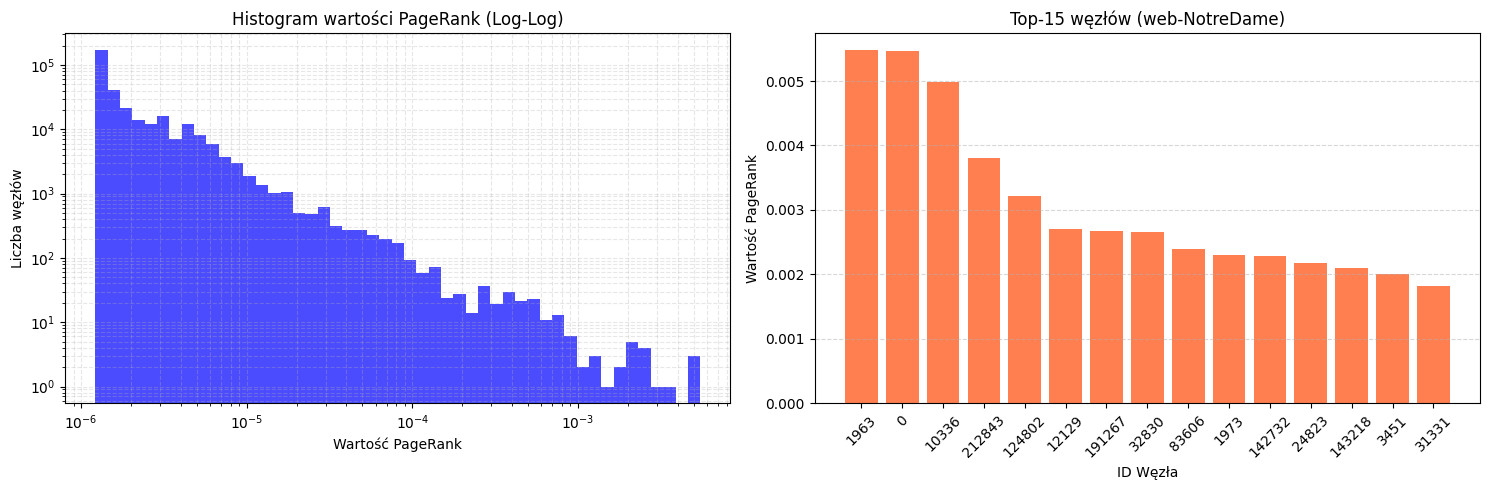

In [36]:
filepath = "web-NotreDame.txt"

adj_list, n_nodes = load_snap_dataset(filepath)

d_param = 0.85
start_time = time.time()
pr_alg, delta_history, iterations = pagerank_algorithm(adj_list, n_nodes, d=d_param)
print(f"Finished in {iterations} iterations. Time: {time.time() - start_time:.2f}s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


pr_nonzero = pr_alg[pr_alg > 0] 
ax1.hist(pr_nonzero, bins=np.logspace(np.log10(min(pr_nonzero)), np.log10(max(pr_nonzero)), 50), color='blue', alpha=0.7)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title("Histogram wartości PageRank (Log-Log)", fontsize=12)
ax1.set_xlabel("Wartość PageRank", fontsize=10)
ax1.set_ylabel("Liczba węzłów", fontsize=10)
ax1.grid(True, which="both", linestyle="--", alpha=0.3)

top_15_indices = np.argsort(pr_alg)[::-1][:15]
top_15_values = pr_alg[top_15_indices]

ax2.bar(range(15), top_15_values, color='coral')
ax2.set_xticks(range(15))
ax2.set_xticklabels([str(idx) for idx in top_15_indices], rotation=45)
ax2.set_title("Top-15 węzłów (web-NotreDame)", fontsize=12)
ax2.set_xlabel("ID Węzła", fontsize=10)
ax2.set_ylabel("Wartość PageRank", fontsize=10)
ax2.grid(axis='y', linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Rozkład wartości PageRank

Wygenerowane wykresy dla zbioru `web-NotreDame` obejmującego ponad 325 tysięcy wierzchołków ilustrują naturę sieci bezskalowych: zjawisko "bogaty staje się bogatszy".

1. **Histogram:**
   Wykres po lewej stronie demaskuje klasyczny rozkład potęgowy z tzw. ciężkim ogonem (heavy-tail distribution). Zdecydowana większość wierzchołków w sieci (rzędu $10^5$) posiada minimalną wartość PageRank (okolice $10^{-6}$). Jednocześnie istnieje zaledwie garstka węzłów, które osiągają wartości o kilka rzędów wielkości wyższe. Oznacza to, że struktura linków w rzeczywistym internecie jest silnie scentralizowana wokół głównych stron.

2. **Wykres słupkowy:**
   Wykres po prawej stronie ukazuje bezwzględną dominację najważniejszych stron. Lider rankinguzgromadził wartość PageRank na poziomie ponad 0.005. Przy założeniu równomiernego rozkładu znaczenia, średnia wartość dla każdego węzła wynosiłaby zaledwie ok. 0.000003. Oznacza to, że najważniejszy węzeł jest ponad 1800 razy ważniejszy niż przeciętna strona w tym grafie.

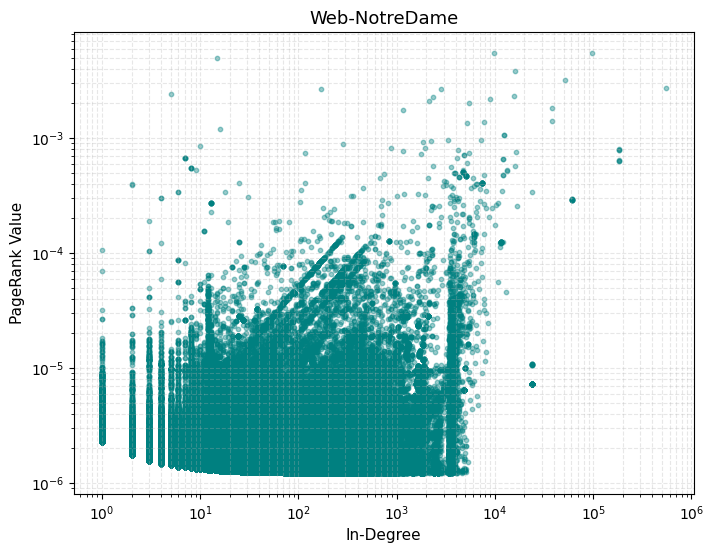

In [37]:
in_degrees = np.zeros(n_nodes)
for u, neighbors in adj_list.items():
    for nei in neighbors:
        in_degrees[neighbors] += 1

# Filter out nodes with 0 in-degree to avoid issues with log scale
mask = (in_degrees > 0) & (pr_alg > 0)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(in_degrees[mask], pr_alg[mask], alpha=0.4, color='teal', s=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("In-Degree", fontsize=11)
ax.set_ylabel("PageRank Value", fontsize=11)
ax.set_title("Web-NotreDame", fontsize=13)
ax.grid(True, which="both", ls="--", alpha=0.3)

plt.show()

### Zależność PageRank od stopnia wejściowego

Wykres punktowy w skali log-log przedstawia relację między liczbą linków przychodzących do danej strony a jej ostateczną wartością PageRank. Wykres ten stanowi fundamentalny dowód na nieliniowość algorytmu i potwierdza zasadę: **jakość linków jest ważniejsza niż ich ilość**.

Analizując rozrzut punktów, można wyciągnąć następujące wnioski:
1. **Globalny trend:** Istnieje zauważalna, pozytywna korelacja – węzły z większą liczbą linków wejściowych mają statystycznie wyższą szansę na wysoki PageRank: chmura punktów wznosi się ku prawej stronie.
2. **Rozrzut pionowy :** W lewej części wykresu widoczne są węzły o bardzo małym stopniu wejściowym, których PageRank jest niezwykle wysoki. Jest to dowód na to, że nawet pojedynczy link pochodzący od bardzo ważnego wierzchołka potrafi wywindować stronę na szczyt rankingu.
3. **Rozrzut poziomy ** W prawej dolnej części widoczne są wierzchołki, do których prowadzą tysiące linków, a mimo to ich PageRank pozostaje bliski minimum. Dowodzi to, że algorytm jest odporny na sztuczne generowanie ruchu – masowe linkowanie z mało znaczących stron nie przekłada się na realny wzrost autorytetu.
4. **Struktura pasmowa:** Widoczne w dolnej części wykresu diagonalne pasma reprezentują grupy stron oddalonych o taką samą liczbę kroków od węzłów brzegowych lub otrzymujących linki wyłącznie od stron o najniższym możliwym rankingu.

## 5. Analiza wrażliwości na współczynnik tłumienia ($d$)

Zbadano wpływ parametru $d \in \{0.5, 0.6, 0.75, 0.85, 0.9\}$  na zachowanie algorytmu. Parametr ten określa, jak długo surfer podąża za linkami, zanim zdecyduje się na teleportację.

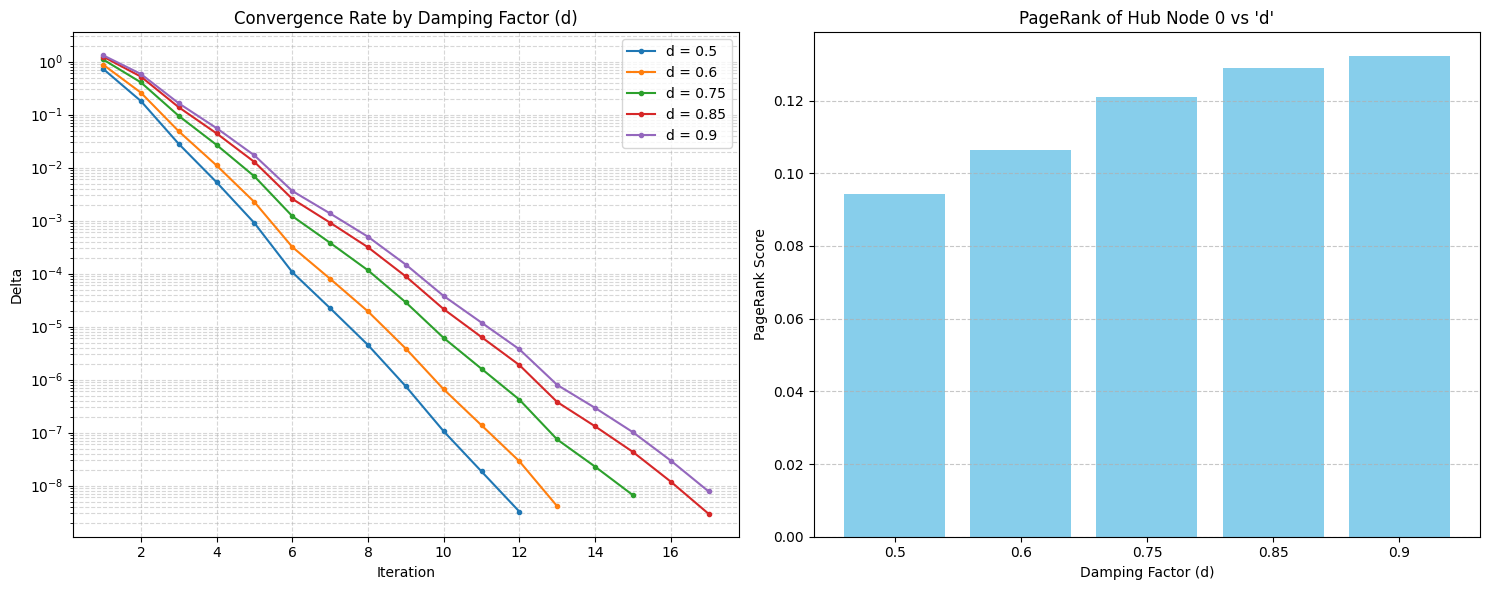

In [31]:
n_exp = 500
G_exp = nx.scale_free_graph(n=n_exp, seed=42)
G_exp = nx.DiGraph(G_exp)
adj_exp = nx.to_dict_of_lists(G_exp)

d_values = [0.5, 0.6, 0.75, 0.85, 0.9]
convergence_histories = {}
top_nodes_ranks = {}

target_node = 0 

for d in d_values:
    pr_vec, history, _ = pagerank_algorithm(adj_exp, n_exp, d=d)
    convergence_histories[d] = history
    top_nodes_ranks[d] = pr_vec[target_node]

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for d, history in convergence_histories.items():
    ax1.plot(range(1, len(history) + 1), history, marker='o', markersize=3, label=f"d = {d}")

ax1.set_yscale('log')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Delta")
ax1.set_title("Convergence Rate by Damping Factor (d)")
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# Plot 2: Bar chart of a hub node's PageRank vs 'd'
ax2.bar([str(d) for d in d_values], list(top_nodes_ranks.values()), color='skyblue')
ax2.set_xlabel("Damping Factor (d)")
ax2.set_ylabel("PageRank Score")
ax2.set_title(f"PageRank of Hub Node {target_node} vs 'd'")
ax2.grid(axis='y', ls="--", alpha=0.7)

plt.tight_layout()
plt.show()

* **Szybkość zbieżności:** Niższa wartość $d$ wymusza częstszą teleportację, co drastycznie przyspiesza zbieżność algorytmu. Wyższe wartości $d$ zwiększają wpływ struktury grafu, wydłużając czas obliczeń.
* **Rozkład wyników:** Przy wyższym $d$ huby zyskują jeszcze więcej znaczenia. Gdy $d$ maleje, wektor wyników zaczyna "wypłaszczać się", zbliżając się do wektora preferencji $e$.

## 6. Personalizacja wyszukiwania: Zmiana wektora preferencji $e$

Wektor teleportacji $e$ domyślnie zakłada równomierny rozkład $e = \frac{1}{n}\mathbf{1}$. Model ten zakłada, że znudzony surfer przenosi się na całkowicie losową stronę w sieci.

Możemy jednak zasymulować **Spersonalizowany PageRank**, poprzez skupienie masy wektora $e$ na konkretnych wierzchołkach, co symuluje zainteresowania użytkownika.

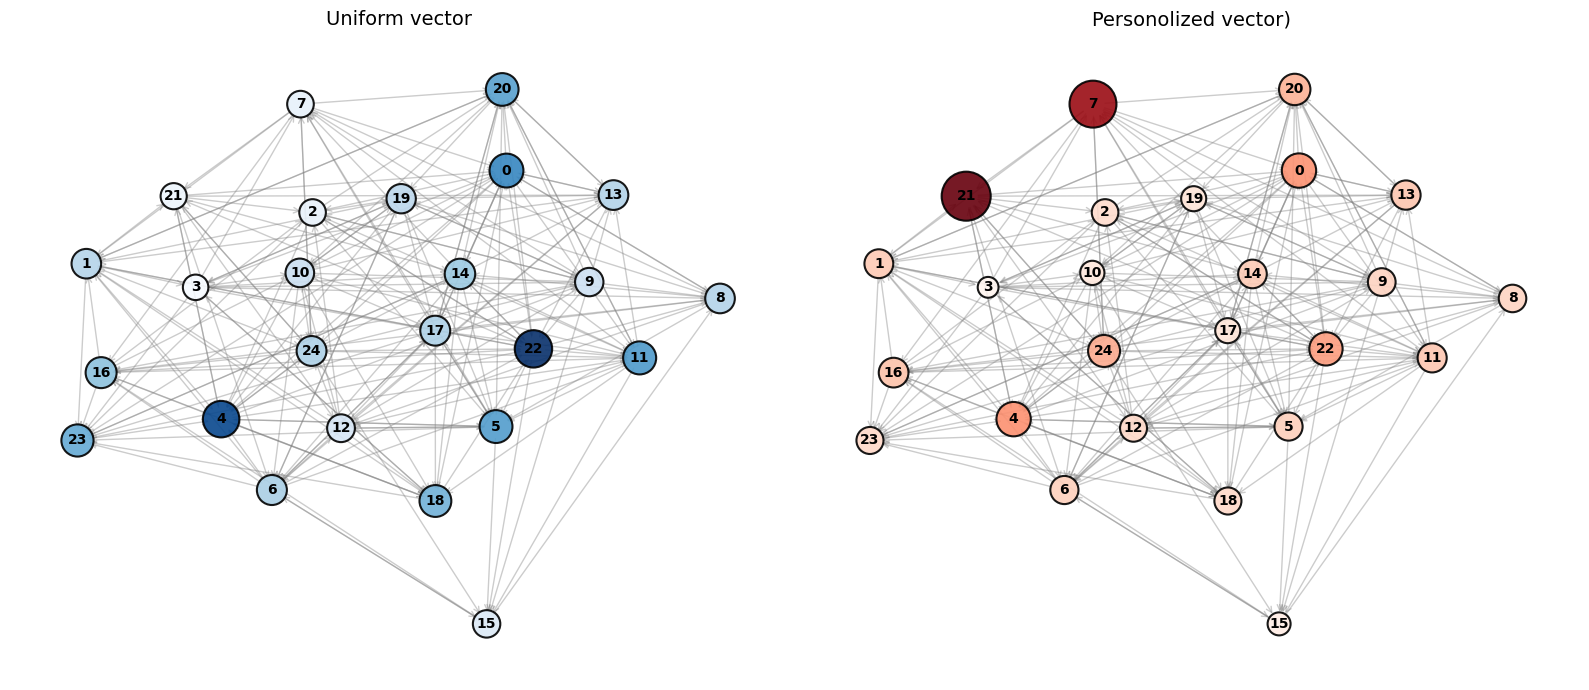

In [48]:
# --- Setup a small graph for visual comparison ---
n_small = 25
G_small = nx.erdos_renyi_graph(n=n_small, p=0.3, directed=True, seed=42)


adj_small = nx.to_dict_of_lists(G_small)

# --- 1. Uniform PageRank ---
e_uniform = np.ones(n_small) / n_small
pr_uniform, _, _ = pagerank_algorithm(adj_small, n_small, e=e_uniform)

# --- 2. Personalized PageRank ---
target_nodes = [7, 21]
e_personal = np.zeros(n_small)
e_personal[target_nodes[0]] = 0.5
e_personal[target_nodes[1]] = 0.5
pr_personal, _, _ = pagerank_algorithm(adj_small, n_small, e=e_personal)

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

pos = nx.spring_layout(G_small, seed=100)

def draw_pagerank_graph(ax, G, pos, pr_vector, title, colormap):
    node_sizes = [pr_vector[node] * 12000 for node in G.nodes()]
    
    node_colors = [pr_vector[node] for node in G.nodes()]
        
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                           cmap=colormap, edgecolors="black", linewidths=1.5, alpha=0.9, ax=ax)
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=10, 
                           edge_color="gray", alpha=0.4, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color="black", font_weight="bold", ax=ax)
    
    ax.set_title(title, fontsize=14)
    ax.axis("off")

draw_pagerank_graph(ax1, G_small, pos, pr_uniform, "Uniform vector", plt.cm.Blues)

title_pers = f"Personolized vector)"
draw_pagerank_graph(ax2, G_small, pos, pr_personal, title_pers, plt.cm.Reds)

plt.tight_layout()
plt.show()

* **Strona lewa (Paleta niebieska, Jednorodny wektor $e$):** Dystrybucja znaczenia wynika wyłącznie ze struktury linków. Węzły ciemniejsze do których prowadzi najwięcej optymalnych ścieżek. Węzły 7 i 21 mają w tym scenariuszu marginalne znaczenie.
* **Strona prawa (Paleta czerwona, Spersonalizowany wektor $e$):** Mimo identycznej topologii grafu, układ sił drastycznie się zmienia. Węzły 7 i 21 stają się wizualnie dominujące, ponieważ pochłaniają masę prawdopodobieństwa z globalnej teleportacji. 


Wizualizacja pokazuje, że wektor teleportacji może być potężnym narzędziem pozwalającym na sterowanie uwagą algorytmu i dostosowywanie wyników do preferencji konkretnego użytkownika.